# Orquestração do Pipeline: PGA Regression with PSA Clusters

Este notebook replica passo a passo a execução do `main.py` recém-refatorado. A execução em células facilita a análise dos dados passo-a-passo, validações dos DataFrames intermediários e a visualização dos resultados dos modelos.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

import config
from data_loader import load_pga_data, load_psa_data, get_common_records, get_psa_station_earthquake_ids
from preprocessing import split_train_test_by_earthquake, create_features, remove_outliers
from clustering import split_psa_columns, calculate_psa_means, generate_clusters, add_clusters
from modeling import (
    get_preprocessor, build_linear_regression, build_polynomial_regression, 
    build_elasticnet, build_random_forest, build_xgboost, build_dnn_model
)
from evaluation import model_experiment, save_pipelines, save_experiments_results
from visualization import plot_regression_scatter, plot_error_analysis

C:\Users\galdi\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carregamento e Preparação Inicial dos Dados

In [2]:
print("Carregando os dados...")
df_pga = load_pga_data(config.RAW_EARTHQUAKES_PGA_PATH)
df_psa = load_psa_data(config.RAW_EARTHQUAKES_PSA_PATH)
psa_ids = get_psa_station_earthquake_ids(df_psa)

print(f"   -> Total de registros PGA originais: {len(df_pga)}")
print(f"   -> Total de registros PSA originais (estações-terremoto únicas): {len(psa_ids)}")
print(f"   -> Terremotos únicos na base PGA: {df_pga['earthquake_id'].nunique()}")

# Verificação de registros ausentes
pga_ids = set(df_pga['station_earthquakeid'])
missing_in_pga = psa_ids - pga_ids
missing_in_psa = pga_ids - psa_ids
print(f"   -> Registros em PSA mas ausentes em PGA: {len(missing_in_pga)}")
print(f"   -> Registros em PGA mas ausentes em PSA: {len(missing_in_psa)}")

print("\nFiltrando registros comuns entre PGA e PSA...")
df_pga_common = get_common_records(df_pga, df_psa)
print(f"   -> Total de registros PGA após filtro: {len(df_pga_common)}")

print("\nAplicando Engenharia de Atributos (Feature Engineering)...")
df_pga_common = create_features(df_pga_common)
display(df_pga_common.head(3))

Carregando os dados...
   -> Total de registros PGA originais: 1663
   -> Total de registros PSA originais (estações-terremoto únicas): 1616
   -> Terremotos únicos na base PGA: 65
   -> Registros em PSA mas ausentes em PGA: 0
   -> Registros em PGA mas ausentes em PSA: 19

Filtrando registros comuns entre PGA e PSA...
   -> Total de registros PGA após filtro: 1643

Aplicando Engenharia de Atributos (Feature Engineering)...


,date,time,magnitude,institution,entity,station_key,station_name,peak_ground_acceleration,quality,file,...,calculated_incidence_angle,source_off_shore,calculated_azimuth,earthquake_id,station_earthquakeid,log_incidence_angle,magnitude_cat,peak_ground_acceleration_cat,calculated_epicentral_distance_cat,depth_cat
0,2018-02-16,23:39:39,7.2,I de I-UNAM,GRO,SLU2,SAN LUIS DE LA LOMA 2,2.94,A,SLU21802.161,...,2.750710,False,-68.901392,20180216233939,SLU2-20180216233939,1.011859,3,2,5,2
1,2018-02-16,23:39:39,7.2,I de I-UNAM,OAX,SMLC,SAN MARTIN LOS CANSECO,23.38,A,SMLC1802.161,...,6.278245,False,70.398457,20180216233939,SMLC-20180216233939,1.837090,3,6,2,2
2,2018-02-16,23:39:39,7.2,I de I-UNAM,MIC,SNJE,SAN JERONIMO,3.51,A,SNJE1802.161,...,2.105055,False,-53.423946,20180216233939,SNJE-20180216233939,0.744342,3,2,6,2


## 2. Separação (Train/Test Split) & Limpeza de Outliers

In [3]:
print("Realizando o split (Treino/Teste) agrupado por earthquake_id...")
df_train, df_test = split_train_test_by_earthquake(
    df_pga_common, 
    test_size=0.2, 
    random_state=config.RANDOM_STATE
)
total_records = len(df_pga_common)
print(f"   -> Train records: {len(df_train)} ({len(df_train)/total_records:.1%})")
print(f"   -> Test records: {len(df_test)} ({len(df_test)/total_records:.1%})")

overlap = set(df_train['earthquake_id']).intersection(set(df_test['earthquake_id']))
print(f"   -> Sobreposição de terremotos entre Treino e Teste (deve ser 0): {len(overlap)}")

print("\nRemovendo Outliers (Apenas no conjunto de Treino)...")
df_train_clean = remove_outliers(
    df_train, 
    features=config.SELECTED_ATTRIBUTES, 
    n_neighbors=200
)
outliers_removidos = len(df_train) - len(df_train_clean)
print(f"   -> Foram removidos {outliers_removidos} outliers do conjunto de treino.")

Realizando o split (Treino/Teste) agrupado por earthquake_id...
   -> Train records: 1302 (79.2%)
   -> Test records: 341 (20.8%)
   -> Sobreposição de terremotos entre Treino e Teste (deve ser 0): 0

Removendo Outliers (Apenas no conjunto de Treino)...
   -> Foram removidos 2 outliers do conjunto de treino.


## 3. Processamento e Clusterização (KMeans) das Matrizes Espectrais

In [4]:
print("Processando e Clusterizando os dados de PSA...")
train_ids = df_train['earthquake_id'].unique()
test_ids = df_test['earthquake_id'].unique()

df_psa_train, df_psa_test = split_psa_columns(df_psa, train_ids, test_ids)
train_means = calculate_psa_means(df_psa_train)
test_means = calculate_psa_means(df_psa_test)

cluster_mapping = {
    'spectral_coefs': 'clusters_spectral_coefs',
    'spectral_means': 'clusters_spectral_means',
    'spectral_horiz_means': 'clusters_spectral_horiz_means',
    'spectral_vert_means': 'clusters_spectral_vert_means'
}

for mean_key, cluster_col in cluster_mapping.items():
    print(f"   -> Gerando e atribuindo (KMeans k=4) para: {cluster_col}")
    clusters_dict = generate_clusters(
        train_means[mean_key], 
        test_means[mean_key], 
        k=4, 
        random_state=config.RANDOM_STATE
    )
    df_train_clean, _ = add_clusters(df_train_clean, clusters_dict, cluster_col)
    df_test, _ = add_clusters(df_test, clusters_dict, cluster_col)

print("\nClusterização concluída. Datasets possuem agora labels de cluster.")
display(df_train_clean[config.CLUSTER_COLUMNS].head(3))

Processando e Clusterizando os dados de PSA...
   -> Gerando e atribuindo (KMeans k=4) para: clusters_spectral_coefs
   -> Gerando e atribuindo (KMeans k=4) para: clusters_spectral_means
   -> Gerando e atribuindo (KMeans k=4) para: clusters_spectral_horiz_means
   -> Gerando e atribuindo (KMeans k=4) para: clusters_spectral_vert_means

Clusterização concluída. Datasets possuem agora labels de cluster.


,clusters_spectral_coefs,clusters_spectral_means,clusters_spectral_horiz_means,clusters_spectral_vert_means
0,2,2,1,2
1,1,2,1,1
2,1,1,3,3


## 4. Setup e Treinamento de Modelos

In [5]:
def get_tuned_params(model_key):
    param_file = os.path.join(config.RESULTS_DIR, f"tuning_results_{model_key}.json")
    if os.path.exists(param_file):
        with open(param_file, 'r', encoding='utf-8') as f:
            return json.load(f).get('best_params', {})
    return {}

experiments = {}
trained_pipelines = {}

def train_evaluate_dnn(df_train, df_test, preprocessor, model_name, dnn_params):
    print(f"Executando experimento: {model_name}...")
    X_train_dnn, X_valid_dnn, y_train_dnn, y_valid_dnn = train_test_split(
        df_train, df_train['peak_ground_acceleration'], test_size=0.2, random_state=config.RANDOM_STATE
    )
    
    tf_x_train = preprocessor.fit_transform(X_train_dnn)
    tf_x_valid = preprocessor.transform(X_valid_dnn)
    
    dnn_kwargs = {}
    if 'n_hidden' in dnn_params: dnn_kwargs['n_hidden_layers'] = dnn_params['n_hidden']
    if 'n_neurons' in dnn_params: dnn_kwargs['n_neurons'] = dnn_params['n_neurons']
    if 'activation' in dnn_params: dnn_kwargs['activation'] = dnn_params['activation']
    if 'learning_rate' in dnn_params: dnn_kwargs['learning_rate'] = dnn_params['learning_rate']
    
    model = build_dnn_model(**dnn_kwargs)
    es = EarlyStopping(monitor='val_rmse', mode='min', verbose=0, patience=10, restore_best_weights=True)
    
    model.fit(tf_x_train, y_train_dnn, epochs=100, callbacks=[es], validation_data=(tf_x_valid, y_valid_dnn), verbose=0)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    predictions = pipeline.predict(df_test)
    test_rmse = root_mean_squared_error(df_test['peak_ground_acceleration'], predictions)
    r2 = r2_score(df_test['peak_ground_acceleration'], predictions)
    
    confidence = 0.95
    squared_errors = (predictions.flatten() - df_test['peak_ground_acceleration'].values) ** 2
    conf_interval = np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
                             loc=np.mean(squared_errors), scale=stats.sem(squared_errors)))
    
    experiments[model_name] = [test_rmse, r2, conf_interval[0], conf_interval[1]]
    trained_pipelines[model_name] = pipeline
    print(f"  -> Test RMSE: {test_rmse:.4f}")

rf_params = get_tuned_params('rf')
xgb_params = get_tuned_params('xgb')
dnn_params = get_tuned_params('dnn')

In [6]:
print("--- Treinando modelos BASE (Sem features de Cluster) ---")
preprocessor_base = get_preprocessor(num_attributes=config.NUM_ATTRIBUTES)

models_base = [
    ('Linear Regression', build_linear_regression(preprocessor_base)),
    ('Polynomial Regression', build_polynomial_regression(preprocessor_base)),
    ('Polynomial ElasticNet', build_elasticnet(preprocessor_base)),
    ('Random Forest', build_random_forest(preprocessor_base, **rf_params)),
    ('XGBoost', build_xgboost(preprocessor_base, **xgb_params))
]

for name, pipeline in models_base:
    model_experiment(df_train_clean, df_test, pipeline, experiments, name, target_col='peak_ground_acceleration')
    trained_pipelines[name] = pipeline

train_evaluate_dnn(df_train_clean, df_test, preprocessor_base, 'Deep Neural Network', dnn_params)

--- Treinando modelos BASE (Sem features de Cluster) ---
Executando experimento: Linear Regression...
  -> Train RMSE: 43.9574
  -> Test RMSE: 49.0827
  -> Test R2: 0.4449
Executando experimento: Polynomial Regression...
  -> Train RMSE: 38.7224
  -> Test RMSE: 47.2452
  -> Test R2: 0.4857
Executando experimento: Polynomial ElasticNet...
  -> Train RMSE: 40.0670
  -> Test RMSE: 47.9756
  -> Test R2: 0.4697
Executando experimento: Random Forest...
  -> Train RMSE: 31.3161
  -> Test RMSE: 48.0240
  -> Test R2: 0.4686
Executando experimento: XGBoost...
  -> Train RMSE: 25.3812
  -> Test RMSE: 51.5856
  -> Test R2: 0.3869
Executando experimento: Deep Neural Network...
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
  -> Test RMSE: 47.5852


C:\Users\galdi\AppData\Roaming\Python\Python310\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [7]:
print("\n--- Treinando modelos COM features de Cluster ---")
for cluster_col in config.CLUSTER_COLUMNS:
    if cluster_col not in df_train_clean.columns:
        continue
        
    print(f"\n>>> Avaliando Cluster Feature: {cluster_col}")
    preprocessor_cluster = get_preprocessor(num_attributes=config.NUM_ATTRIBUTES, cat_attributes=[cluster_col])
    
    models_cluster = [
        (f'Linear Regression with PSA {cluster_col}', build_linear_regression(preprocessor_cluster)),
        (f'Polynomial Regression with PSA {cluster_col}', build_polynomial_regression(preprocessor_cluster)),
        (f'Polynomial ElasticNet with PSA {cluster_col}', build_elasticnet(preprocessor_cluster)),
        (f'Random Forest with PSA {cluster_col}', build_random_forest(preprocessor_cluster)),
        (f'XGBoost with PSA {cluster_col}', build_xgboost(preprocessor_cluster))
    ]
    
    for name, pipeline in models_cluster:
        model_experiment(df_train_clean, df_test, pipeline, experiments, name, target_col='peak_ground_acceleration')
        trained_pipelines[name] = pipeline
        
    train_evaluate_dnn(df_train_clean, df_test, preprocessor_cluster, f'Deep Neural Network with PSA {cluster_col}', dnn_params)


--- Treinando modelos COM features de Cluster ---

>>> Avaliando Cluster Feature: clusters_spectral_coefs
Executando experimento: Linear Regression with PSA clusters_spectral_coefs...
  -> Train RMSE: 43.8106
  -> Test RMSE: 49.1139
  -> Test R2: 0.4442
Executando experimento: Polynomial Regression with PSA clusters_spectral_coefs...
  -> Train RMSE: 37.8099
  -> Test RMSE: 47.1892
  -> Test R2: 0.4869
Executando experimento: Polynomial ElasticNet with PSA clusters_spectral_coefs...
  -> Train RMSE: 39.3748
  -> Test RMSE: 47.9407
  -> Test R2: 0.4705
Executando experimento: Random Forest with PSA clusters_spectral_coefs...
  -> Train RMSE: 29.6228
  -> Test RMSE: 47.2760
  -> Test R2: 0.4850
Executando experimento: XGBoost with PSA clusters_spectral_coefs...
  -> Train RMSE: 7.1104
  -> Test RMSE: 86.0351
  -> Test R2: -0.7054
Executando experimento: Deep Neural Network with PSA clusters_spectral_coefs...
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
  -> Test RMSE: 47.0414

>>> Avaliando 

C:\Users\galdi\AppData\Roaming\Python\Python310\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


  -> Train RMSE: 29.2704
  -> Test RMSE: 46.5462
  -> Test R2: 0.5008
Executando experimento: XGBoost with PSA clusters_spectral_means...
  -> Train RMSE: 6.2733
  -> Test RMSE: 56.0102
  -> Test R2: 0.2772
Executando experimento: Deep Neural Network with PSA clusters_spectral_means...
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
  -> Test RMSE: 50.2080

>>> Avaliando Cluster Feature: clusters_spectral_horiz_means
Executando experimento: Linear Regression with PSA clusters_spectral_horiz_means...
  -> Train RMSE: 43.7052
  -> Test RMSE: 48.5613
  -> Test R2: 0.4567
Executando experimento: Polynomial Regression with PSA clusters_spectral_horiz_means...
  -> Train RMSE: 35.4341
  -> Test RMSE: 51.3911
  -> Test R2: 0.3915
Executando experimento: Polynomial ElasticNet with PSA clusters_spectral_horiz_means...
  -> Train RMSE: 38.2851


C:\Users\galdi\AppData\Roaming\Python\Python310\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


  -> Test RMSE: 46.6419
  -> Test R2: 0.4988
Executando experimento: Random Forest with PSA clusters_spectral_horiz_means...
  -> Train RMSE: 28.6481
  -> Test RMSE: 46.1992
  -> Test R2: 0.5082
Executando experimento: XGBoost with PSA clusters_spectral_horiz_means...
  -> Train RMSE: 6.2150
  -> Test RMSE: 58.7729
  -> Test R2: 0.2041
Executando experimento: Deep Neural Network with PSA clusters_spectral_horiz_means...
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
  -> Test RMSE: 49.5935

>>> Avaliando Cluster Feature: clusters_spectral_vert_means
Executando experimento: Linear Regression with PSA clusters_spectral_vert_means...
  -> Train RMSE: 43.7503
  -> Test RMSE: 48.2326
  -> Test R2: 0.4640
Executando experimento: Polynomial Regression with PSA clusters_spectral_vert_means...
  -> Train RMSE: 37.3236
  -> Test RMSE: 46.8703
  -> Test R2: 0.4938
Executando experimento: Polynomial ElasticNet with PSA clusters_spectral_vert_means...
  -> Train RMSE: 39.1572


C:\Users\galdi\AppData\Roaming\Python\Python310\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


  -> Test RMSE: 46.4875
  -> Test R2: 0.5021
Executando experimento: Random Forest with PSA clusters_spectral_vert_means...
  -> Train RMSE: 29.9424
  -> Test RMSE: 46.7516
  -> Test R2: 0.4964
Executando experimento: XGBoost with PSA clusters_spectral_vert_means...
  -> Train RMSE: 4.8791
  -> Test RMSE: 57.5920
  -> Test R2: 0.2358
Executando experimento: Deep Neural Network with PSA clusters_spectral_vert_means...
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
  -> Test RMSE: 49.3622


C:\Users\galdi\AppData\Roaming\Python\Python310\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


## 5. Resultados e Visualizações Finais

In [8]:
print("Salvando Resultados e Pipelines...")
os.makedirs(config.RESULTS_DIR, exist_ok=True)
save_experiments_results(experiments, os.path.join(config.RESULTS_DIR, 'experiments_results.csv'))
save_pipelines(trained_pipelines, config.TRAINED_PIPELINES_DIR)

df_results = pd.DataFrame.from_dict(
    experiments, 
    orient='index', 
    columns=['Test RMSE', 'R2', 'CI Lower', 'CI Upper']
)
df_results.index.name = 'Model'
df_results.sort_values(by='Test RMSE', ascending=True, inplace=True)
display(df_results)

Salvando Resultados e Pipelines...
Resultados dos experimentos salvos em: ./paper_1_results_revised/experiments_results.csv
Salvando pipeline: Linear Regression
Salvando pipeline: Polynomial Regression
Salvando pipeline: Polynomial ElasticNet
Salvando pipeline: Random Forest
Salvando pipeline: XGBoost
Salvando pipeline: Deep Neural Network
Salvando pipeline: Linear Regression with PSA clusters_spectral_coefs
Salvando pipeline: Polynomial Regression with PSA clusters_spectral_coefs
Salvando pipeline: Polynomial ElasticNet with PSA clusters_spectral_coefs
Salvando pipeline: Random Forest with PSA clusters_spectral_coefs
Salvando pipeline: XGBoost with PSA clusters_spectral_coefs
Salvando pipeline: Deep Neural Network with PSA clusters_spectral_coefs
Salvando pipeline: Linear Regression with PSA clusters_spectral_means
Salvando pipeline: Polynomial Regression with PSA clusters_spectral_means
Salvando pipeline: Polynomial ElasticNet with PSA clusters_spectral_means
Salvando pipeline: Rando

,Test RMSE,R2,CI Lower,CI Upper
Model,,,,
Random Forest with PSA clusters_spectral_horiz_means,46.199181,0.508237,56.769391,88.646321
Polynomial ElasticNet with PSA clusters_spectral_vert_means,46.487464,0.502081,56.769391,88.646321
Polynomial ElasticNet with PSA clusters_spectral_means,46.528720,0.501196,56.769391,88.646321
Random Forest with PSA clusters_spectral_means,46.546168,0.500822,56.769391,88.646321
Polynomial ElasticNet with PSA clusters_spectral_horiz_means,46.641902,0.498767,56.769391,88.646321
Random Forest with PSA clusters_spectral_vert_means,46.751561,0.496407,56.769391,88.646321
Polynomial Regression with PSA clusters_spectral_vert_means,46.870334,0.493845,56.769391,88.646321
Deep Neural Network with PSA clusters_spectral_coefs,47.041406,0.490143,36.688638,55.495329
Polynomial Regression with PSA clusters_spectral_coefs,47.189192,0.486935,56.769391,88.646321


Visualizações de Desempenho:



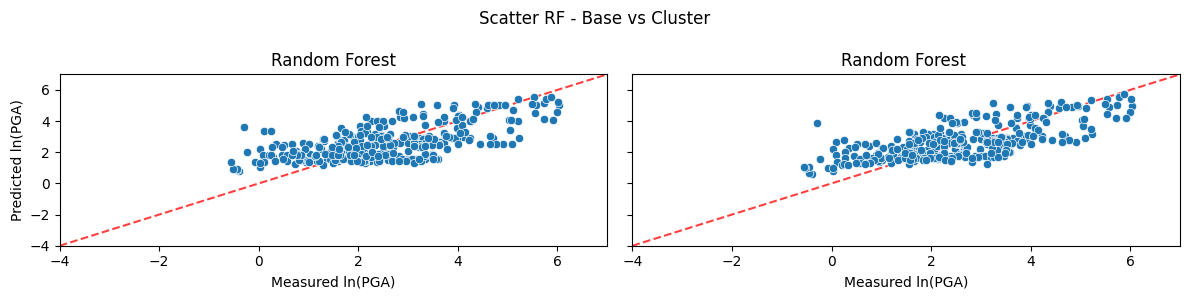

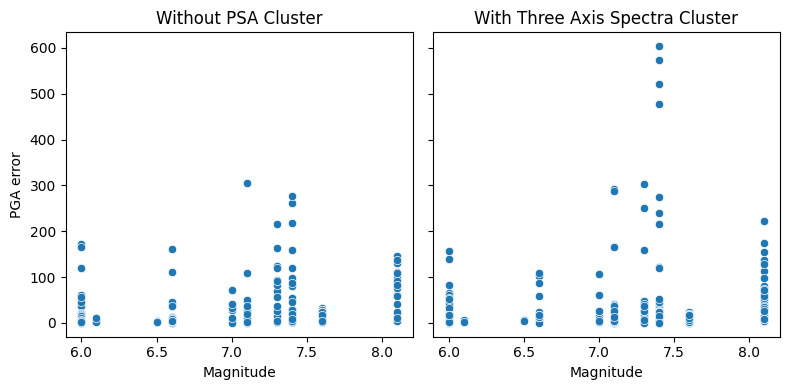

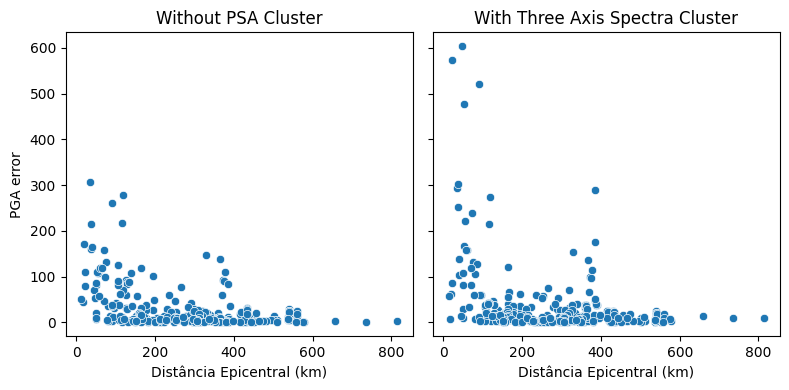

In [9]:
print("Visualizações de Desempenho:\n")
scatter_models = ['Random Forest', f'Random Forest with PSA {config.CLUSTER_COLUMNS[0]}']
if all(m in trained_pipelines for m in scatter_models):
    plot_regression_scatter(trained_pipelines, df_test, scatter_models, "Scatter RF - Base vs Cluster")
    plt.show()

xgb_base_name = 'XGBoost'
xgb_cluster_name = f'XGBoost with PSA {config.CLUSTER_COLUMNS[0]}'

if xgb_base_name in trained_pipelines and xgb_cluster_name in trained_pipelines:
    pred_base = trained_pipelines[xgb_base_name].predict(df_test)
    pred_cluster = trained_pipelines[xgb_cluster_name].predict(df_test)
    
    plot_error_analysis(df_test, pred_base, pred_cluster, 'magnitude', 'Magnitude')
    plt.show()
    
    plot_error_analysis(df_test, pred_base, pred_cluster, 'calculated_epicentral_distance', 'Distância Epicentral (km)')
    plt.show()